In [77]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def f_one_max(population: np.ndarray):
    return np.sum(population, axis=1)

def f_deceptive_one_max(population: np.ndarray):
    d = population.shape[1]
    fitness = np.sum(population, axis=1)
    fitness[fitness == 0] = d + 1

    return fitness

def opt_k_deceptive(d: int, k: int) -> int:
    blocks, tail = divmod(d, k)
    return blocks * (k + 1) + ((tail + 1) if tail > 0 else 0)

def f_k_deceptive_one_max(population: np.ndarray, k) -> np.ndarray:
    n_samples, d = population.shape

    num_blocks = d // k
    remainder = d % k

    if num_blocks > 0:
        main_part = population[:, :num_blocks*k]
        reshaped = main_part.reshape(n_samples, num_blocks, k)

        block_sums = np.sum(reshaped, axis=2)
        block_scores = np.where(block_sums == 0, k + 1, block_sums)

        total_fitness = np.sum(block_scores, axis=1)
    else:
        total_fitness = np.zeros(n_samples)

    if remainder > 0:
        tail_part = population[:, num_blocks*k:]
        tail_sums = np.sum(tail_part, axis=1)
        tail_scores = np.where(tail_sums == 0, remainder + 1, tail_sums)
        total_fitness += tail_scores

    return total_fitness

def random_population(prob_vector, pop_size, rng):
    d = len(prob_vector)
    return rng.random((pop_size, d)) < prob_vector


In [40]:
def pbil(rng, d, eval_f, pop_size, learn_rate, mut_prob, mut_shift, max_iter=100):
    prob_vector = np.full(d, fill_value=0.5, dtype=np.float32)
    history = []

    for i in range(max_iter):
        population = random_population(prob_vector, pop_size, rng)

        ranks = eval_f(population)

        best_id = ranks.argmax()
        best_fitness = ranks[best_id]
        best_ind = population[best_id]

        history.append(best_fitness)

        prob_vector = prob_vector * (1 - learn_rate) + best_ind * learn_rate

        mutation_mask = rng.random(d) < mut_prob
        mutation_dir = rng.random(d) < 0.5
        prob_vector[mutation_mask] = prob_vector[mutation_mask] * (1 - mut_shift) + mutation_dir[mutation_mask] * mut_shift

    return history

def umda(rng, d, eval_f, pop_size, selection_rate=0.5, max_iter=100):

    prob_vector = np.full(d, fill_value=0.5, dtype=np.float32)
    history = []

    select_k = int(pop_size * selection_rate)

    for i in range(max_iter):
        population = random_population(prob_vector, pop_size, rng)

        fitness_values = eval_f(population)

        best_fitness = np.max(fitness_values)
        history.append(best_fitness)

        top_indices = np.argsort(fitness_values)[-select_k:]
        selected_population = population[top_indices]

        prob_vector = np.mean(selected_population, axis=0)
        prob_vector = np.clip(prob_vector, 0.01, 0.99)

    return history

def cga(rng, d, eval_f, learn_rate=None, max_iter=1000):

    if learn_rate is None:
        learn_rate = 1.0 / d

    prob_vector = np.full(d, fill_value=0.5, dtype=np.float32)

    history = []

    for i in range(max_iter):
        x_a = (rng.random(d) < prob_vector).astype(int)
        x_b = (rng.random(d) < prob_vector).astype(int)

        fit_a = eval_f(x_a.reshape(1, -1))[0]
        fit_b = eval_f(x_b.reshape(1, -1))[0]

        # x_a will be the better one
        if fit_a < fit_b:
            x_a, x_b = x_b, x_a

        history.append(fit_a)

        if fit_a != fit_b:
            prob_vector += learn_rate * (x_a - x_b)

        prob_vector = np.clip(prob_vector, 0.0, 1.0)

    return history

In [44]:
def mimic(rng, d, eval_f, pop_size, percentile=0.5, max_iter=50):
    def get_entropy(p):
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

    def get_mi_structure(pop):
        n, dim = pop.shape
        p1 = np.mean(pop, axis=0)
        p11 = (pop.T @ pop) / n

        p10 = p1[:, None] - p11
        p01 = p1[None, :] - p11
        p00 = 1.0 - (p11 + p10 + p01)

        h_x = get_entropy(p1)

        def plogp(arr):
            a = np.clip(arr, 1e-9, 1)
            return a * np.log2(a)
        h_xy = -(plogp(p11) + plogp(p10) + plogp(p01) + plogp(p00))

        mi = h_x[:, None] + h_x[None, :] - h_xy
        np.fill_diagonal(mi, 0)
        return mi, p1, p11, h_x

    population = rng.integers(0, 2, (pop_size, d))
    keep_size = int(pop_size * percentile)
    history = []

    for i in range(max_iter):
        scores = eval_f(population)
        history.append(np.max(scores))

        if np.var(scores) < 1e-5:
            history.extend([np.max(scores)] * (max_iter - i - 1))
            break

        top_indices = np.argsort(scores)[-keep_size:]
        selected = population[top_indices]

        mi, p1, p11, h_x = get_mi_structure(selected)

        remaining = set(range(d))
        start_node = np.argmin(h_x)
        perm = [start_node]
        remaining.remove(start_node)

        while remaining:
            last = perm[-1]
            cands = list(remaining)
            best_idx = np.argmax(mi[last, cands])
            best_node = cands[best_idx]
            perm.append(best_node)
            remaining.remove(best_node)

        new_pop = np.zeros((pop_size, d), dtype=int)

        root = perm[0]
        new_pop[:, root] = (rng.random(pop_size) < p1[root]).astype(int)


        for j in range(d - 1):
            u, v = perm[j], perm[j+1]
            p_u = p1[u]
            p_uv = p11[u, v]

            prob_1 = p_uv / p_u if p_u > 1e-9 else 0.5
            p_u0 = 1 - p_u
            prob_0 = (p1[v] - p_uv) / p_u0 if p_u0 > 1e-9 else 0.5

            prob_1 = np.clip(prob_1, 0, 1)
            prob_0 = np.clip(prob_0, 0, 1)

            prev_vals = new_pop[:, u]
            cond_probs = np.where(prev_vals == 1, prob_1, prob_0)
            new_pop[:, v] = (rng.random(pop_size) < cond_probs).astype(int)

        population = new_pop

    return history

In [91]:
def plot_convergence(hist_pbil, hist_umda, hist_cga, hist_mimic, pop_size_pbil_umda, title="Convergence Comparison", optimum=None):
    plt.figure(figsize=(10, 6))

    x_pop_based = np.arange(len(hist_pbil)) * pop_size_pbil_umda

    plt.plot(x_pop_based, hist_pbil, label='PBIL', linewidth=2)
    plt.plot(x_pop_based, hist_umda, label='UMDA', linewidth=2)
    plt.plot(x_pop_based, hist_mimic, label='MIMIC', linewidth=2, color='red')

    step = int(pop_size_pbil_umda / 2)
    if step < 1: step = 1
    x_cga = np.arange(len(hist_cga)) * 2
    x_cga = x_cga[::step]
    y_cga = hist_cga[::step]
    plt.plot(x_cga, y_cga, label='CGA', linewidth=1.5, alpha=0.8)

    if optimum is not None:
        plt.axhline(y=optimum, color='green', linestyle=':', label=f'Optimum ({optimum})', linewidth=2)

    plt.title(title)
    plt.xlabel('Number of function evaluations')
    plt.ylabel('Best Fitness')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def run(seed):
    D = 40
    POP_SIZE = 100
    ITERATIONS = 500
    CGA_ITERATIONS = (ITERATIONS * POP_SIZE) // 2

    rng = np.random.default_rng(seed)

    print("Running OneMax")
    h_pbil = pbil(rng, D, f_one_max, POP_SIZE, learn_rate=0.1, mut_prob=0.05, mut_shift=0.05, max_iter=ITERATIONS)
    h_umda = umda(rng, D, f_one_max, POP_SIZE, selection_rate=0.5, max_iter=ITERATIONS)
    h_cga  = cga(rng, D, f_one_max, learn_rate=1.0/D, max_iter=CGA_ITERATIONS)

    h_mimic = mimic(rng, D, f_one_max, POP_SIZE, percentile=0.5, max_iter=ITERATIONS)

    plot_convergence(h_pbil, h_umda, h_cga, h_mimic, POP_SIZE, title=f"OneMax, D={D})", optimum=D)

    print("Running Deceptive OneMax")

    h_pbil_dec = pbil(rng, D, f_deceptive_one_max, POP_SIZE, learn_rate=0.1, mut_prob=0.05, mut_shift=0.05, max_iter=ITERATIONS)
    h_umda_dec = umda(rng, D, f_deceptive_one_max, POP_SIZE, selection_rate=0.5, max_iter=ITERATIONS)
    h_cga_dec  = cga(rng, D, f_deceptive_one_max, learn_rate=1.0/D, max_iter=CGA_ITERATIONS)
    h_mimic_dec = mimic(rng, D, f_deceptive_one_max, POP_SIZE, percentile=0.5, max_iter=ITERATIONS)
    plot_convergence(h_pbil_dec, h_umda_dec, h_cga_dec, h_mimic_dec, POP_SIZE, title=f"Deceptive-OneMax, D={D}", optimum=D+1)

    print("Running K-Deceptive OneMax")
    K = 3
    f_deceptive = lambda p: f_k_deceptive_one_max(p, k=K)

    h_pbil_dec = pbil(rng, D, f_deceptive, POP_SIZE, learn_rate=0.1, mut_prob=0.05, mut_shift=0.05, max_iter=ITERATIONS)
    h_umda_dec = umda(rng, D, f_deceptive, POP_SIZE, selection_rate=0.5, max_iter=ITERATIONS)
    h_cga_dec  = cga(rng, D, f_deceptive, learn_rate=1.0/D, max_iter=CGA_ITERATIONS)
    h_mimic_dec = mimic(rng, D, f_deceptive, POP_SIZE, percentile=0.5, max_iter=ITERATIONS)
    plot_convergence(h_pbil_dec, h_umda_dec, h_cga_dec, h_mimic_dec, POP_SIZE, title=f"{K}-Deceptive, D={D}", optimum=opt_k_deceptive(d=D, k=K))

Running OneMax


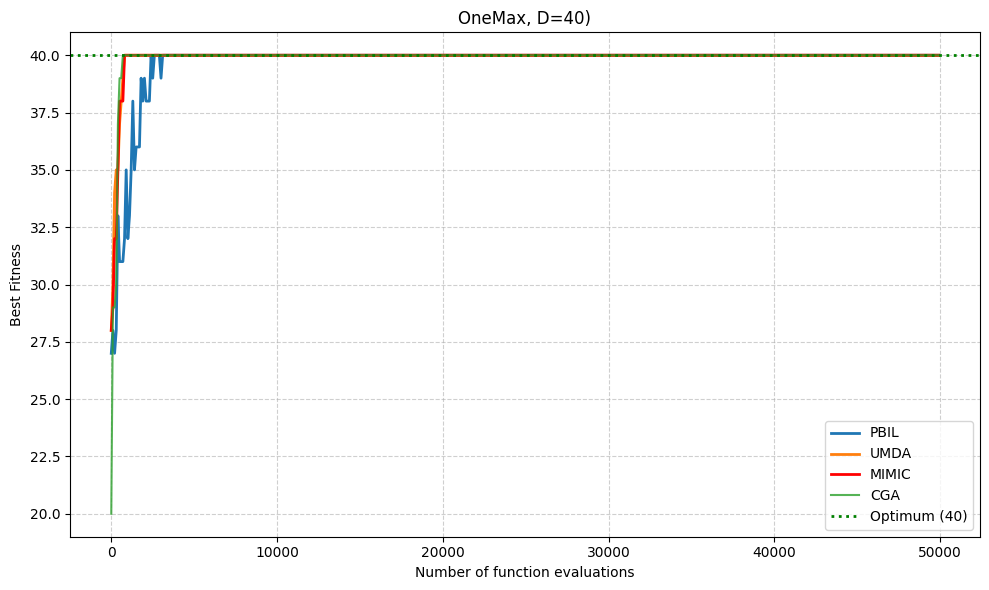

Running Deceptive OneMax


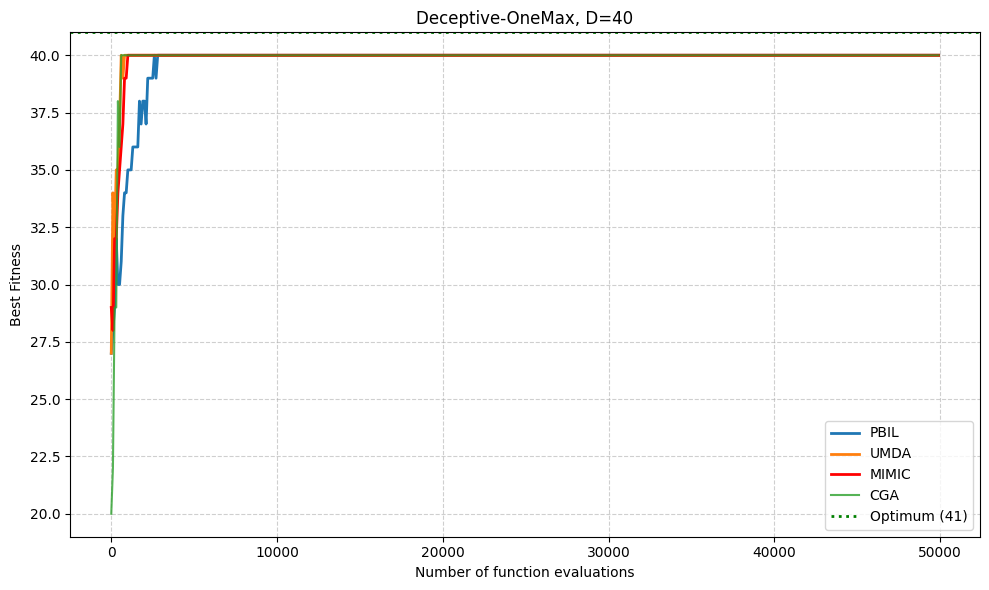

Running K-Deceptive OneMax


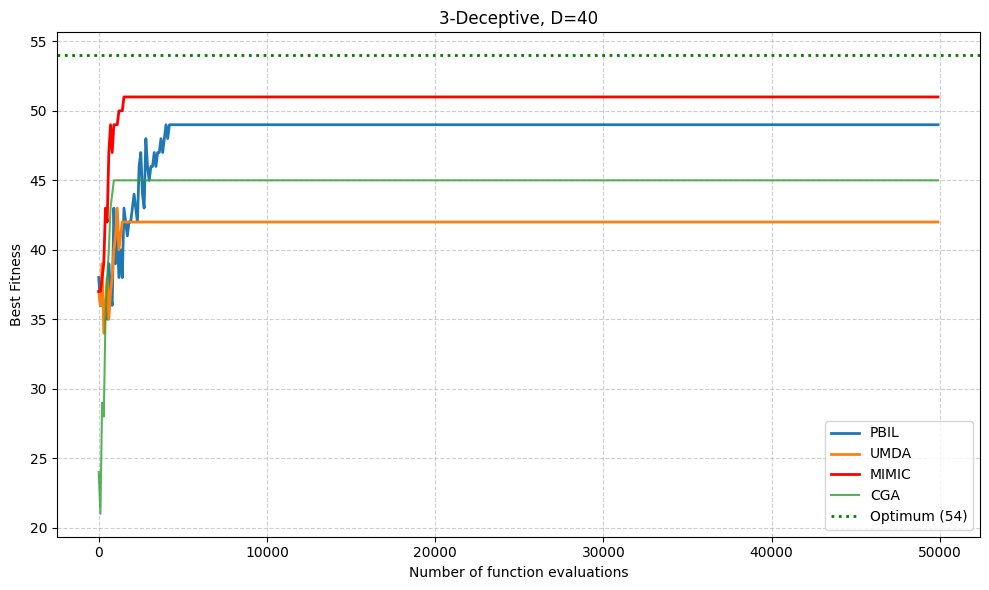

In [92]:
run(40)